# Avance 2. Ingeniería de características
**Equipo 20 · Green stops: infraestructura energética distribuida en corredores**

El reporte describe la preparación de **1,075 sitios y 102 columnas** para estimar el tránsito diario promedio anual (TDPA). Se revisaron faltantes, valores extremos, variables territoriales y su utilidad para la predicción.

En la ejecución incluida, se seleccionó **Filtro + PCA y GBoost sin recorte**, con RMSE de validación **0.7312** y una reducción de **34.93 %** frente al modelo de referencia. Las cifras de estas notas corresponden a las salidas del archivo adjunto.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.feature_selection import VarianceThreshold, f_regression, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler, RobustScaler
from sklearn.metrics.pairwise import haversine_distances
from threadpoolctl import threadpool_limits

SEED = 20
# Mantener límites moderados para evitar saturar el equipo.
threadpool_limits(limits=2)
pd.set_option("display.max_rows", 200, "display.max_columns", 50, "display.width", 200)
# Use siempre la tabla maestra cruda; no reutilice FE_TOP como entrada.
candidatos = [Path.cwd()/"03_PROCESSED", Path.cwd().parent/"03_PROCESSED", Path.cwd(), Path.cwd()/"upload"]
PROCESSED = next((p for p in candidatos if (p/"TOP_Model_Table.csv").exists()), None)
if PROCESSED is None:
    raise FileNotFoundError("Coloque TOP_Model_Table.csv junto al notebook o en 03_PROCESSED")
# Las salidas se guardan en PROCESSED, junto a TOP_Model_Table.csv, como en el original.
decisiones = []
def decidir(paso, decision, razon):
    decisiones.append({"paso": paso, "ambito": "diagnostico exploratorio; no fija CV" if paso in {"4.1","4.2","4.3","4.4"} else "regla de dominio o ajuste final", "decision": decision, "razon": razon})
t = pd.read_csv(PROCESSED/"TOP_Model_Table.csv")
assert t["site_id"].notna().all() and t["site_id"].is_unique, "Revise los identificadores duplicados"
print("Tabla maestra actual:", t.shape)


Tabla maestra actual: (1075, 102)


## 1. Preparación y separación de los datos

La preparación partió de **1,075 sitios y 102 columnas**. Se reservaron **23 sitios** del corredor MEX-095D para la evaluación final. De los 1,052 sitios restantes, se excluyeron **349** por compartir bloques espaciales o encontrarse demasiado cerca del corredor, quedando **703 sitios** para el desarrollo del modelo.

Se asignó una función a las columnas para distinguir cuáles podían utilizarse como predictores y cuáles debían reservarse para identificación, evaluación o control de calidad.

| Grupo | Ejemplos | Uso o motivo de exclusión |
|---|---|---|
| Identificadores y grupos | `site_id`, `ruta`, `carretera`, `cve_mun`, `group_*` | Identifican los registros. Los bloques espaciales organizan la validación, pero no entran como predictores. |
| Variable objetivo | `tdpa`, `log_tdpa` | Representan el tráfico que se desea estimar; utilizarlas como entrada revelaría la respuesta al modelo. |
| Datos del aforo | `pct_C`, `pct_B`, `n_te`, `n_calzadas`, `toll_road` | No se garantiza su disponibilidad en los puntos sin aforo. El peaje se representa con información de la RNC. |
| Coordenadas | `lat`, `lon` | Permiten separar las muestras geográficamente. Se excluyen como predictores para limitar la memorización de ubicaciones. |
| Calidad de asignación vial | `road_dist_m` | Permite revisar si la carretera asignada está cerca del sitio. Se conserva para diagnóstico. |
| Otras exclusiones | `*_min_month`, `mun_agri_top_crop`, `road_jurisdi` | Se omiten por simplificación del análisis; los meses y las categorías territoriales requieren un tratamiento específico. |

Los radios territoriales originales de **5, 10 y 20 km** se mantuvieron. Se agregó una separación de **40 km** entre entrenamiento y evaluación: dos círculos de 20 km dejan de superponerse cuando sus centros están separados más de 40 km. Esta decisión reduce el intercambio de información territorial entre muestras, aunque también disminuye el número de sitios disponibles para entrenar.

La separación se realizó antes de aprender promedios, transformaciones o criterios de selección. El corredor reservado no participó en esos ajustes.


In [2]:
TARGET = "log_tdpa"
# Convertir explícitamente: la cadena 'False' no debe interpretarse como True.
def bool_seguro(s):
    m=s.astype(str).str.strip().str.lower().map({"true":True,"false":False,"1":True,"0":False})
    if m.isna().any(): raise ValueError("is_corridor_test contiene valores no reconocidos")
    return m.astype(bool)
t["is_corridor_test"] = bool_seguro(t["is_corridor_test"])
if not np.isfinite(t[TARGET]).all(): raise ValueError("Objetivo desconocido/no finito: corregir antes de entrenar")
if t["group_block25"].isna().any(): raise ValueError("Faltan grupos espaciales")
if t[["lat","lon"]].isna().any().any(): raise ValueError("Faltan coordenadas para validar espacialmente")
if not (t.lat.between(-90,90)&t.lon.between(-180,180)).all(): raise ValueError("Coordenadas fuera de rango")
# Radio máximo de las características poblacionales: 20 km; 40 km evita círculos superpuestos.
BUFFER_KM = 40.0

def purgar_espacial(entrenamiento, validacion, buffer_km=BUFFER_KM):
    mismo_bloque = entrenamiento.group_block25.isin(validacion.group_block25)
    conservar = ~mismo_bloque
    if len(validacion) and buffer_km > 0:
        a=np.radians(entrenamiento[["lat","lon"]].to_numpy(float))
        b=np.radians(validacion[["lat","lon"]].to_numpy(float))
        distancia = haversine_distances(a,b).min(axis=1)*6371.0088
        conservar &= distancia > buffer_km
    return entrenamiento.loc[conservar].copy()

test = t.loc[t.is_corridor_test].copy()
if test.empty: raise ValueError("No existe prueba externa")
train_pre = t.loc[~t.is_corridor_test].copy()
train = purgar_espacial(train_pre,test)
if len(train)<20: raise ValueError("Entrenamiento insuficiente después del margen espacial")
print(f"Entrenamiento: {len(train)}; excluidos por separación espacial: {len(train_pre)-len(train)}; prueba externa: {len(test)}")
assert not set(train.group_block25)&set(test.group_block25)
ID_COLS = ["site_id", "state_file", "ruta", "carretera", "KM", "lugar_base", "cve_mun",
           "mun_assignment_method", "group_block25", "group_route", "group_state", "is_corridor_test"]
OBJETIVO = ["tdpa", "log_tdpa"]
SOLO_AFORO = ["pct_C", "pct_B", "n_te", "te_list", "n_calzadas", "red", "toll_road", "anio"]
COORDS = ["lat", "lon"]
CALIDAD = ["road_dist_m"]
DOMINIO = [c for c in t.columns if c.endswith("_min_month")] + ["mun_agri_top_crop", "road_jurisdi"]
NO_FEATURES = set(ID_COLS + OBJETIVO + SOLO_AFORO + COORDS + CALIDAD + DOMINIO)

decidir("1", "Excluir columnas que solo existen donde hay aforo SICT",
        "No están disponibles para los CTN del corredor; pct_C y pct_B se miden con el TDPA (fuga)")
decidir("1", "Excluir lat/lon", "Evitar que el modelo memorice ubicaciones; la validación es espacial")

# ¿road_peaje (RNC) coincide con toll_road (SICT)? Si coinciden, perder toll_road no cuesta nada
print(pd.crosstab(t["toll_road"], t["road_peaje"], margins=True))


Entrenamiento: 703; excluidos por separación espacial: 349; prueba externa: 23
road_peaje   No   Si   All
toll_road                 
False       834   11   845
True         60  170   230
All         894  181  1075


### Revisión de la información sobre peajes

Las fuentes SICT y RNC coincidieron en **1,004 sitios (93.40 %)** y presentaron diferencias en **71**: 60 sitios con cuota según SICT y sin peaje según RNC, y 11 en sentido contrario. Se mantuvo el indicador RNC por su disponibilidad en puntos sin aforo.

Una posible explicación es la cercanía entre una autopista de cuota y una carretera libre paralela, que podría afectar la asignación del sitio. Esta explicación permanece como hipótesis. Las diferencias requieren revisar la ubicación, las fechas y los criterios de las fuentes; no se consideró automáticamente que alguna fuera incorrecta.


In [3]:
print(train["road_dist_m"].describe().round(1))
print("Sitios >500 m de la vía:", train.road_dist_m.gt(500).sum())
decidir("1", "Excluir bloques externos y aplicar margen de 40 km", "Evitar compartir bloques y buffers poblacionales de 20 km entre entrenamiento y prueba")
decidir("1", "Conservar asignaciones viales distantes para revisión", "Una distancia grande no demuestra que los atributos sean erróneos")


count    703.0
mean      19.9
std       64.2
min        0.0
25%        1.5
50%        3.5
75%        7.5
max      720.0
Name: road_dist_m, dtype: float64
Sitios >500 m de la vía: 3


### Revisión de la asignación vial

En los 703 sitios de desarrollo, la distancia mediana a la carretera asignada fue de **3.5 m** y el 75 % de los sitios se encontró a **7.5 m o menos**. La media fue de **19.9 m**, influida por algunas distancias elevadas. Se identificaron **3 sitios a más de 500 m**, con un máximo de **720 m**.

Estos registros se conservaron para revisión, ya que una distancia elevada no demuestra por sí sola un error. La comprobación de coordenadas y del segmento vial permitiría determinar si sus atributos corresponden a la carretera adecuada. Las cifras describen los 703 sitios de desarrollo, no toda la base.


## 2. Calidad y construcción de variables territoriales

Se distinguieron los valores que no aplican de aquellos que se desconocen. Las reglas se aplicaron a cada sitio usando sus propios datos, sin utilizar el tráfico que se busca predecir. De esta manera, la construcción de características puede aplicarse tanto a los sitios con aforo como a los puntos CTN destinados a predicción.

| Situación | Tratamiento | Interpretación |
|---|---|---|
| Cociente no aplicable por ausencia de población o establecimientos | Cero acompañado de un indicador estructural | El cero es una representación para el modelo, no una proporción observada. |
| Dato desconocido | Se conserva como faltante y se agrega un indicador | Se completa después, con información del entrenamiento. |
| Categoría vial desconocida | Categoría propia | Evita atribuir una condición vial que no fue observada. |
| Valor incompatible con las reglas de calidad | Se marca como inválido y pasa a faltante | Se conserva el sitio para su revisión. |

Para escolaridad y electricidad se aplicó la hipótesis de que, sin población dentro de 10 km, los valores faltantes podrían no ser aplicables. Esta interpretación debe confirmarse con los metadatos: población cero no demuestra ausencia de viviendas. El cero asignado no representa escolaridad nula ni falta de electricidad.

Se revisaron conteos negativos, proporciones fuera de rango y diferencias incompatibles entre radios, sin eliminar sitios automáticamente. Las proporciones rurales y agrícolas se revisaron entre 0 y 1, mientras que el porcentaje de viviendas con electricidad conserva su escala de 0 a 100.


In [4]:
CAT_COLS = ["road_tipo_vial", "road_circula", "road_cond_pav", "road_recubri", "road_administra", "road_nivel"]

def construir_features(df):
    d=df.copy()
    # Reglas físicas conservadoras; los negativos de temperatura/nivel vial sí son posibles.
    no_neg=[c for c in d.select_dtypes("number") if c.startswith(("denue_n_","pop_","n_localities_","mun_agri_"))
            or c in ["road_carriles","road_ancho","road_velocidad","dist_nearest_locality_m"]]
    props=[c for c in d if c.startswith("rural_pop_share_") or c in ["mun_agri_top_crop_share","mun_agri_irrigated_share","mun_agri_loss_share"]]
    for c in no_neg+props+["pct_dwellings_electricity_10km"]:
        bad=d[c].notna() & ~np.isfinite(d[c])
        if c in no_neg: bad |= d[c].lt(0)
        if c in props: bad |= ~d[c].between(0,1)&d[c].notna()
        if c=="pct_dwellings_electricity_10km": bad |= ~d[c].between(0,100)&d[c].notna()
        d["fe_invalido_"+c]=bad.astype(int)
        d.loc[bad,c]=np.nan
    # Solo cuando existe evidencia de denominador cero se aplica la regla estructural.
    for r in [5,10,20]:
        p=d[f"pop_{r}km"]
        zero=p.eq(0)
        d[f"fe_sin_poblacion_{r}km"]=zero.astype(int)
        cols=[f"rural_pop_share_{r}km"]
        if r==10: cols += ["schooling_mean_10km","pct_dwellings_electricity_10km"]
        for c in cols:
            estructural=d[c].isna()&zero
            d["fe_estructural_"+c]=estructural.astype(int)
            d.loc[estructural,c]=0.0
        d[f"fe_densidad_pob_{r}km"]=p/(np.pi*r*r)
        d[f"fe_pop_urbana_{r}km"]=p*(1-d[f"rural_pop_share_{r}km"])
    cero_est=d.denue_n_est_5km.eq(0)
    d["fe_sin_establecimientos_5km"]=cero_est.astype(int)
    mask=d.denue_sector_shannon_5km.isna()&cero_est
    d["fe_estructural_denue_sector_shannon_5km"]=mask.astype(int)
    d.loc[mask,"denue_sector_shannon_5km"]=0.0
    d["fe_servicios_viajero_5km"]=d.denue_n_food_lodging_5km+d.denue_n_gas_stations_5km+d.denue_n_auto_repair_5km
    def cociente(nombre,a,b,escala=1.0,proporcion=False):
        estructura=b.eq(0)
        valor=escala*a/b.where(b.ne(0))
        # Numerador desconocido sigue siendo desconocido, aun con denominador cero.
        estructura &= a.notna()
        if proporcion: estructura &= a.eq(0)
        valor=valor.mask(estructura,0.0)
        if proporcion:
            invalido=(valor.notna()&~valor.between(0,1)) | (b.eq(0)&a.gt(0))
            d["fe_invalido_"+nombre]=invalido.astype(int)
            valor=valor.mask(invalido)
        d[nombre]=valor
        d["fe_estructural_"+nombre]=estructura.astype(int)
    cociente("fe_share_servicios_viajero",d.fe_servicios_viajero_5km,d.denue_n_est_5km,proporcion=True)
    cociente("fe_share_retail",d.denue_n_retail_5km,d.denue_n_est_5km,proporcion=True)
    cociente("fe_concentracion_pob",d.pop_5km,d.pop_20km,proporcion=True)
    cociente("fe_est_por_1000hab_5km",d.denue_n_est_5km,d.pop_5km,1000)
    cociente("fe_agri_valor_por_ha",d.mun_agri_value_mxn,d.mun_agri_harvested_ha)
    cociente("fe_agri_cosechada_share",d.mun_agri_harvested_ha,d.mun_agri_sown_ha,proporcion=True)
    d["fe_densidad_est_5km"]=d.denue_n_est_5km/(np.pi*25)
    d["fe_densidad_intersecciones_1km"]=d.n_intersections_1km/np.pi
    for a,b in [(5,10),(10,20),(5,20)]:
        valor=d[f"pop_{b}km"]-d[f"pop_{a}km"]
        bad=valor.lt(0)
        d[f"fe_inconsistente_anillo_{a}_{b}km"]=bad.astype(int)
        d[f"fe_pop_anillo_{a}_{b}km"]=valor.mask(bad)
        d[f"fe_densidad_anillo_{a}_{b}km"]=valor.mask(bad)/(np.pi*(b*b-a*a))
    d["fe_hay_gasolinera_5km"]=d.denue_n_gas_stations_5km.gt(0).astype(float).where(d.denue_n_gas_stations_5km.notna())
    d["fe_carriles_4mas"]=d.road_carriles.ge(4).astype(float).where(d.road_carriles.notna())
    d["fe_peaje"]=d.road_peaje.astype(str).str.strip().str.lower().map({"si":1,"sí":1,"yes":1,"no":0})
    d["fe_rnc_sin_atributos"]=d.road_cond_pav.isna().astype(int)
    # Es diagnóstico de fiabilidad de la fuente municipal, no predictor de demanda.
    d["fe_municipio_proxy"]=d.mun_assignment_method.eq("nearest_locality_proxy").astype(int)
    # Crear flags por esquema, incluso si el subconjunto no tiene NaN; evita esquemas distintos.
    originales=[c for c in d.select_dtypes("number") if c not in NO_FEATURES and not c.startswith(("fe_estructural_","fe_invalido_","fe_inconsistente_"))]
    d=d.copy()
    desconocidos={}
    for c in originales:
        d[c]=d[c].replace([np.inf,-np.inf],np.nan)
        desconocidos["fe_desconocido_"+c]=d[c].isna().astype(int)
    d=pd.concat([d,pd.DataFrame(desconocidos,index=d.index)],axis=1).copy()
    for c in CAT_COLS:
        d[c]=d[c].astype("string").fillna("Desconocido").astype(str)
    return d

NO_FEATURES |= {"road_peaje","fe_municipio_proxy"}
train_fe=construir_features(train)
test_fe=construir_features(test)
NUEVAS=[c for c in train_fe if c.startswith("fe_")]
auditoria_faltantes=pd.DataFrame({
    "estructurales":train_fe.filter(regex="^fe_estructural_").sum(),
    "desconocidos":train_fe.filter(regex="^fe_desconocido_").sum(),
    "invalidos":train_fe.filter(regex="^fe_invalido_").sum()}).fillna(0).astype(int)
print(auditoria_faltantes.loc[auditoria_faltantes.sum(axis=1)>0].to_string())
decidir("2", "Faltantes estructurales=0 + flag; desconocidos=NaN + flag", "No atribuir población, comercios o agricultura inexistentes a datos ausentes")


                                               estructurales  desconocidos  invalidos
fe_desconocido_fe_carriles_4mas                            0             9          0
fe_desconocido_road_carriles                               0             9          0
fe_estructural_denue_sector_shannon_5km                   14             0          0
fe_estructural_fe_concentracion_pob                       61             0          0
fe_estructural_fe_est_por_1000hab_5km                    138             0          0
fe_estructural_fe_share_retail                            14             0          0
fe_estructural_fe_share_servicios_viajero                 14             0          0
fe_estructural_pct_dwellings_electricity_10km            109             0          0
fe_estructural_rural_pop_share_10km                      109             0          0
fe_estructural_rural_pop_share_20km                       61             0          0
fe_estructural_rural_pop_share_5km                    

### 2.1 Nuevas variables y resultados de calidad

En el entrenamiento se registraron faltantes estructurales de proporción rural en **138 sitios a 5 km**, **109 a 10 km** y **61 a 20 km**. Asimismo, se identificaron **14 casos sin establecimientos** y **9 registros con carriles desconocidos**. Estos conteos pueden corresponder a los mismos sitios y no deben sumarse.

Se conservaron las características del análisis inicial y se ampliaron con indicadores de distribución poblacional y actividad territorial. Su construcción y propósito se resumen a continuación.

| Característica | Construcción | Aporte al análisis |
|---|---|---|
| Servicios al viajero | Suma de establecimientos de alimentos y hospedaje, gasolineras y talleres | Resume actividades potencialmente relacionadas con quienes circulan por carretera. |
| Proporción de servicios y comercio | Servicios o comercios divididos entre el total de establecimientos | Describe la composición económica de sitios con distinto número de negocios. |
| Presencia de gasolineras | Indicador de existencia, con valores 0/1 | Distingue disponibilidad de ausencia, además del conteo de gasolineras. |
| Concentración poblacional | Población a 5 km dividida entre población a 20 km | Describe qué parte de la población del entorno se concentra cerca del sitio. |
| Establecimientos por habitante | Negocios por cada 1,000 habitantes a 5 km | Relaciona la actividad comercial con la población residente. |
| Cuatro o más carriles | Indicador que separa vías con menos de cuatro carriles de las que tienen cuatro o más | Introduce una agrupación sencilla del número de carriles. |
| Peaje y atributos viales faltantes | Indicadores de cuota y falta de información vial | Representa una condición de la vía y la disponibilidad de sus atributos. |
| Valor agrícola por hectárea | Valor de producción dividido entre superficie cosechada | Describe intensidad económica agrícola a escala municipal. |
| Proporción de superficie cosechada | Superficie cosechada dividida entre superficie sembrada | Compara ambas superficies; no equivale al rendimiento físico de un cultivo. |
| Densidades territoriales | Población, establecimientos o intersecciones divididos entre el área correspondiente | Expresa las cantidades por km² y facilita su interpretación. |
| Población entre radios y población urbana | Diferencias de población entre radios y combinación con la proporción rural | Describe distribución y composición poblacional del entorno. |

Estas variables utilizan los datos disponibles. Las densidades calculadas con áreas fijas pueden repetir información de los conteos y, por ello, se someten a la selección posterior. Los anillos solo se calculan cuando los conteos acumulados son compatibles. Las áreas corresponden a círculos completos, y los datos agrícolas mantienen su alcance municipal.


### 2.2 Codificación de categorías

Los tipos y condiciones de las vías se representaron mediante **one-hot**, que crea indicadores por categoría. Así se evita imponer un orden artificial, como considerar que una avenida tiene un valor intermedio entre una calle y una carretera. El nivel vial también se trató como etiqueta, aunque su registro sea numérico.

Las categorías con menos de **10 observaciones** en el entrenamiento se agruparon para evitar demasiadas columnas con pocos casos. Los valores desconocidos conservaron una categoría propia y las categorías nuevas se manejaron sin volver a ajustar la codificación con datos de evaluación.

Los indicadores binarios conservaron sus valores 0/1. Cuando presentaron faltantes, se completaron con el valor más frecuente del entrenamiento. No se utilizó codificación basada en el tráfico objetivo.

La codificación se ajustó únicamente con el entrenamiento de cada partición. En la muestra de desarrollo, **522 sitios** correspondieron a carreteras y **173** carecieron de información sobre pavimento, recubrimiento y administración. Este patrón describe disponibilidad de datos, sin implicar que las vías carezcan de esos atributos.


In [5]:
for c in CAT_COLS: print(c, train_fe[c].value_counts().to_dict())
decidir("2", "One-hot entrenado dentro de cada fold; desconocidos como categoría", "Sin orden artificial; categorías nuevas se manejan sin usar validación")


road_tipo_vial {'Carretera': 522, 'Calle': 72, 'Avenida': 51, 'Enlace': 20, 'Boulevard': 11, 'Privada': 9, 'Camino': 8, 'Cerrada': 3, 'Calzada': 2, 'Circuito': 2, 'Prolongación': 2, 'Retorno U': 1}
road_circula {'Dos sentidos': 451, 'Un sentido': 251, 'Cerrada en ambos sentidos': 1}
road_cond_pav {'Con pavimento': 523, 'Desconocido': 173, 'Sin pavimento': 7}
road_recubri {'Asfalto': 499, 'Desconocido': 173, 'Concreto': 23, 'Tierra': 6, 'Bloques': 1, 'Grava': 1}
road_administra {'Federal': 303, 'Estatal': 207, 'Desconocido': 173, 'Municipal': 15, 'N/D': 5}
road_nivel {'0': 664, '1': 30, '2': 5, '-1': 4}


### 2.3 Modelo de referencia

Se utilizó un modelo de referencia, o baseline, basado en el promedio del tráfico logarítmico por tipo de vía y presencia de peaje. Su propósito fue determinar si las variables adicionales y los modelos más complejos aportaban una mejora frente a una regla sencilla.

Los promedios se calcularon nuevamente en cada entrenamiento. Cuando una combinación de tipo de vía y peaje no estaba representada, se utilizó el promedio general de ese entrenamiento.

En la tabla descriptiva, las carreteras sin peaje presentaron una media de **8.96** en escala logarítmica, frente a **9.87** en las carreteras con peaje, con **406** y **116 sitios**, respectivamente. La diferencia muestra una asociación entre grupos, sin demostrar que el cobro de peaje cause mayor tráfico.


In [6]:
class BaselineGrupo(BaseEstimator, RegressorMixin):
    def __init__(self, grupos=("road_tipo_vial", "fe_peaje")):
        self.grupos = grupos
    def fit(self, X, y):
        g = list(self.grupos)
        self.medias_ = pd.Series(np.asarray(y), index=X.index).groupby([X[c] for c in g]).mean()
        self.global_ = float(np.mean(y))
        return self
    def predict(self, X):
        idx = pd.MultiIndex.from_frame(X[list(self.grupos)])
        return self.medias_.reindex(idx).fillna(self.global_).to_numpy()

base = BaselineGrupo().fit(train_fe, train_fe[TARGET])
print(base.medias_.round(2).rename("media_log_tdpa").to_frame()
      .join(train_fe.groupby(["road_tipo_vial", "fe_peaje"]).size().rename("n")))
decidir("2", "Baseline = media de log_tdpa por tipo de vía y cuota", "Referencia simple pedida por el asesor")

                         media_log_tdpa    n
road_tipo_vial fe_peaje                     
Avenida        0                   9.85   51
Boulevard      0                  10.57   11
Calle          0                   9.47   72
Calzada        0                  10.23    2
Camino         0                   9.79    8
Carretera      0                   8.96  406
               1                   9.87  116
Cerrada        0                  10.09    3
Circuito       0                   8.88    2
Enlace         0                   9.59   20
Privada        0                   9.75    9
Prolongación   0                   9.89    2
Retorno U      0                  10.04    1


## 3. Revisión y tratamiento de valores atípicos

**Variable objetivo.** Se mantuvo `log_tdpa`, el logaritmo natural del TDPA. Esta representación reduce el peso de diferencias muy grandes entre sitios. Las métricas posteriores se interpretan en esa escala y no directamente como vehículos diarios.

**Detección de extremos.** Los valores extremos se identificaron a partir de la distribución de cada variable, sin considerarlos automáticamente errores. Se utilizaron límites basados en la parte central de los datos, mediante el rango intercuartílico (IQR). Para continuas no negativas se aplicó `log1p` al calcular esos límites, lo que modera las colas largas. Se agregaron indicadores para señalar los casos detectados.

**Tratamiento comparado.** Se evaluó conservar los extremos o limitar las magnitudes situadas fuera de los percentiles **0.5 y 99.5** del entrenamiento. Este recorte no eliminó registros. La variable objetivo, los indicadores binarios y las proporciones protegidas no se recortaron. Detectar un extremo y decidir recortarlo fueron pasos distintos; en los resultados de esta versión se seleccionó la alternativa sin recorte.

**Transformación y escalamiento.** Las continuas seleccionadas con asimetría absoluta mayor que 1 se transformaron con **Yeo–Johnson**, que admite ceros y valores negativos. Esta propiedad resulta útil porque varios conteos contienen ceros y algunas variables climáticas pueden ser negativas. Después se aplicó **escalamiento robusto**, basado en la mediana y la dispersión central, para reducir la sensibilidad a extremos. Las demás continuas seleccionadas recibieron ese escalamiento sin la transformación previa.

**Faltantes y clima.** Los faltantes continuos se completaron con la mediana del entrenamiento, y los binarios con el valor más frecuente. El bloque climático destinado a PCA se estandarizó por separado para que las diferencias de unidades no dominaran sus componentes. Si Yeo–Johnson presentó un problema numérico, el procedimiento contempló el escalamiento robusto como respaldo.

Todos los ajustes se realizaron dentro de cada partición. La información de validación recibió los parámetros aprendidos en el entrenamiento, sin intervenir en su cálculo. Este procedimiento permite comparar alternativas y reduce el riesgo de fuga de información.


In [7]:
num_cand=[c for c in train_fe.select_dtypes("number") if c not in NO_FEATURES and c not in CAT_COLS]
# Solo diagnósticos. Estas listas NO se usan para construir los modelos de CV.
BINARIAS=[c for c in num_cand if train_fe[c].dropna().nunique()<=2 and set(train_fe[c].dropna()).issubset({0,1})]
continuas=[c for c in num_cand if c not in BINARIAS]
asim=train_fe[continuas].skew().rename("asimetria").to_frame()
asim["transformacion"]=np.where(asim.asimetria.abs()>1,"Yeo-Johnson","RobustScaler")
SESGADAS=asim.index[asim.transformacion.eq("Yeo-Johnson")].tolist()
print("Candidatas:",len(num_cand));print(asim.sort_values("asimetria",key=abs,ascending=False).head(20))


Candidatas: 234
                            asimetria transformacion
fe_est_por_1000hab_5km      19.539618    Yeo-Johnson
fe_agri_valor_por_ha        16.479749    Yeo-Johnson
pop_nearest_locality        13.956391    Yeo-Johnson
mun_agri_loss_share          9.654232    Yeo-Johnson
fe_pop_urbana_5km            7.047899    Yeo-Johnson
pop_5km                      6.967455    Yeo-Johnson
fe_densidad_pob_5km          6.967455    Yeo-Johnson
fe_agri_cosechada_share     -5.775729    Yeo-Johnson
road_carriles                5.443631    Yeo-Johnson
mun_agri_value_mxn           4.656312    Yeo-Johnson
dist_nearest_locality_m      4.463319    Yeo-Johnson
fe_share_servicios_viajero   4.313887    Yeo-Johnson
fe_densidad_anillo_5_10km    4.247222    Yeo-Johnson
fe_pop_anillo_5_10km         4.247222    Yeo-Johnson
road_ancho                   4.211923    Yeo-Johnson
denue_n_large_est_5km        4.035816    Yeo-Johnson
fe_pop_urbana_10km           3.913873    Yeo-Johnson
pop_10km                     3

### Interpretación de las distribuciones

Las mayores asimetrías mostradas correspondieron a establecimientos por 1,000 habitantes (**19.54**), valor agrícola por hectárea (**16.48**) y población de la localidad más cercana (**13.96**). La relación de superficie cosechada/sembrada presentó asimetría negativa (**−5.78**).

Estas cifras describen distribuciones con valores concentrados y colas pronunciadas; no demuestran errores de datos. En una relación por habitante o por hectárea, un valor elevado también puede deberse a un denominador pequeño, por lo que su interpretación requiere considerar ambas cantidades.

Las gráficas comparan establecimientos, población a 10 km, distancia a la localidad e intersecciones antes y después de la transformación. Permiten observar cambios en concentración y dispersión. La utilidad predictiva se comprobó mediante la comparación de modelos, mientras que las transformaciones se volvieron a ajustar dentro de cada entrenamiento.


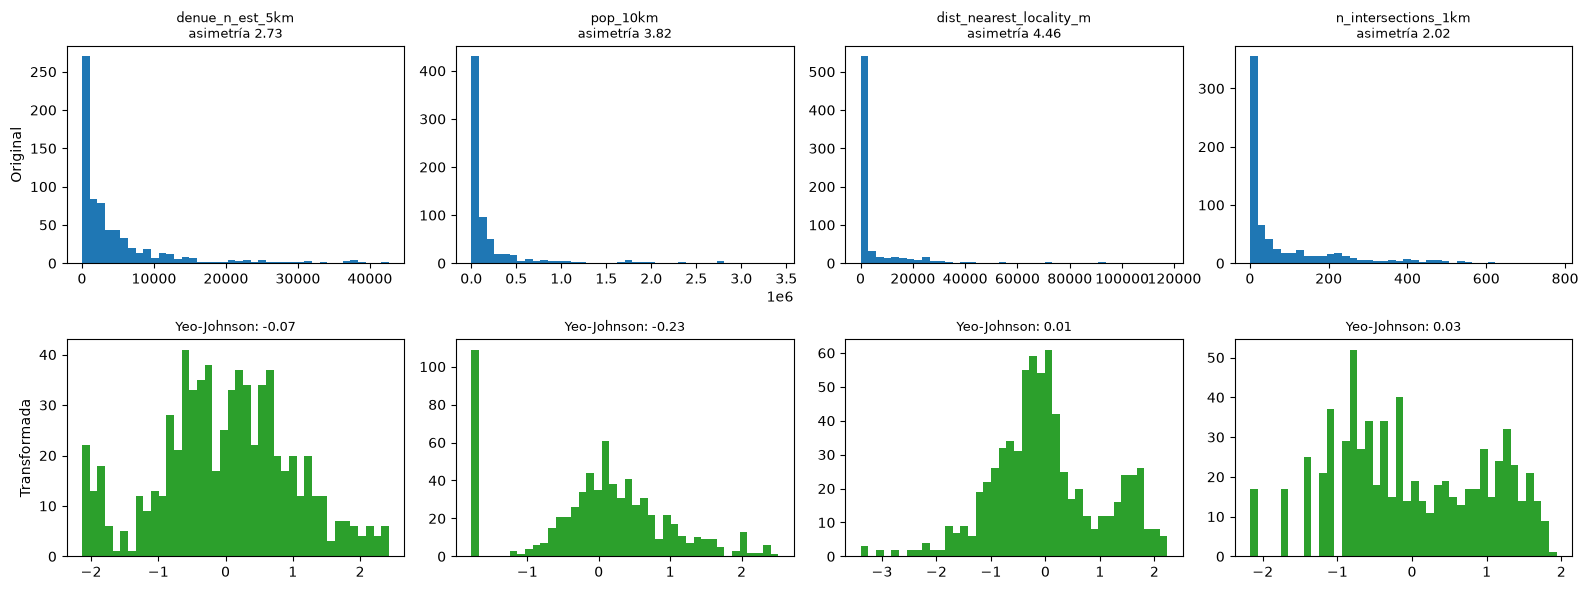

In [8]:
ejemplos = [c for c in ["denue_n_est_5km", "pop_10km", "dist_nearest_locality_m", "n_intersections_1km"] if c in num_cand]
fig, ax = plt.subplots(2, len(ejemplos), figsize=(4 * len(ejemplos), 6))
for j, c in enumerate(ejemplos):
    x = train_fe[[c]].fillna(train_fe[c].median())
    xt = PowerTransformer(method="yeo-johnson").fit_transform(x).ravel()
    ax[0, j].hist(x[c], bins=40); ax[0, j].set_title(f"{c}\nasimetría {x[c].skew():.2f}", fontsize=9)
    ax[1, j].hist(xt, bins=40, color="tab:green"); ax[1, j].set_title(f"Yeo-Johnson: {pd.Series(xt).skew():.2f}", fontsize=9)
ax[0, 0].set_ylabel("Original"); ax[1, 0].set_ylabel("Transformada")
plt.tight_layout(); plt.show()

In [9]:
class PreparadorSeguro(BaseEstimator, TransformerMixin):
    """Todas las decisiones aprendidas viven en fit; transform nunca usa y."""
    def __init__(self, modo="Filtro + PCA", recortar=False, umbral_corr=0.85):
        self.modo=modo
        self.recortar=recortar
        self.umbral_corr=umbral_corr

    def _numericas(self,X):
        z=X.reindex(columns=self.num_entrada_).copy().replace([np.inf,-np.inf],np.nan)
        self_flags={}
        for c in self.continuas_:
            a=np.log1p(z[c]) if self.log_iqr_[c] else z[c]
            lo,hi=self.limites_iqr_[c]
            self_flags["atipico__"+c]=((a<lo)|(a>hi)).astype(float)
            if self.recortar and c in self.limites_recorte_:
                l,h=self.limites_recorte_[c]
                z[c]=z[c].clip(l,h)
        z=z.fillna(self.medianas_).fillna(0.0)
        return z,pd.DataFrame(self_flags,index=X.index)

    def fit(self,X,y):
        self.num_entrada_=[c for c in X.select_dtypes("number") if c not in NO_FEATURES and c not in CAT_COLS]
        raw=X[self.num_entrada_].replace([np.inf,-np.inf],np.nan)
        self.medianas_=raw.median().fillna(0.0)
        self.binarias_=[c for c in self.num_entrada_ if raw[c].dropna().nunique()<=2 and set(raw[c].dropna()).issubset({0,1})]
        # Los desconocidos binarios se imputan por moda del entrenamiento, nunca 0.5.
        for c in self.binarias_:
            moda=raw[c].mode()
            self.medianas_[c]=float(moda.iloc[0]) if len(moda) else 0.0
        self.continuas_=[c for c in self.num_entrada_ if c not in self.binarias_]
        self.log_iqr_={};self.limites_iqr_={};self.limites_recorte_={};aud=[]
        for c in self.continuas_:
            a=raw[c].dropna()
            self.log_iqr_[c]=len(a)>0 and a.min()>=0
            u=np.log1p(a) if self.log_iqr_[c] else a
            q1,q3=u.quantile([.25,.75]);iqr=q3-q1
            if np.isfinite(iqr) and iqr>0: lo,hi=q1-1.5*iqr,q3+1.5*iqr
            else: lo,hi=u.quantile([.005,.995])
            self.limites_iqr_[c]=(lo,hi)
            # No recortar proporciones, porcentajes, binarias o flags.
            protegida=("share" in c or c=="fe_concentracion_pob" or c.startswith("pct_") or c.startswith(("fe_invalido_","fe_estructural_","fe_desconocido_","fe_inconsistente_")))
            if not protegida and len(a): self.limites_recorte_[c]=tuple(a.quantile([.005,.995]))
            aud.append(dict(variable=c,n_observados=len(a),n_atipicos=int(((u<lo)|(u>hi)).sum()),
                escala_IQR="log1p" if self.log_iqr_[c] else "original",limite_IQR_inf=lo,limite_IQR_sup=hi,
                cuantile_inf=self.limites_recorte_.get(c,(np.nan,np.nan))[0],
                cuantile_sup=self.limites_recorte_.get(c,(np.nan,np.nan))[1],recortada=self.recortar and c in self.limites_recorte_))
        self.auditoria_atipicos_=pd.DataFrame(aud)
        z,flags=self._numericas(X)
        num=[c for c in self.num_entrada_ if z[c].nunique()>1 and not c.startswith("allsky_sfc_sw_dwn")]
        clima=[c for c in num if c.startswith(("prectotcorr","t2m","ws10m"))]
        self.pca_cols_=clima if self.modo=="Filtro + PCA" else []
        if self.pca_cols_: num=[c for c in num if c not in self.pca_cols_]
        yy=pd.Series(np.asarray(y),index=X.index)
        if self.modo!="Todas" and num:
            # Relevancia lineal dentro del fold (diagnóstico adicional MI en sección 4.3).
            _,p=f_regression(z[num],yy)
            relevantes=[c for c,pp in zip(num,p) if np.isfinite(pp) and pp<.05]
            if relevantes: num=relevantes
            rho=z[num].corrwith(yy,method="spearman").abs().fillna(0).sort_values(ascending=False,kind="stable")
            corr=z[num].corr(method="spearman").abs().fillna(0)
            elegidas=[]
            for c in rho.index:
                if not any(corr.loc[c,k]>=self.umbral_corr for k in elegidas): elegidas.append(c)
            num=elegidas
        self.num_seleccionadas_=num
        self.cat_seleccionadas_=[c for c in CAT_COLS if c in X and X[c].nunique()>1]
        if self.modo!="Todas":
            cats=[]
            for c in self.cat_seleccionadas_:
                gs=[yy.loc[g.index].to_numpy() for _,g in X.groupby(c) if len(g)>=5]
                if len(gs)>1:
                    _,p=stats.f_oneway(*gs)
                    if np.isfinite(p) and p<.05: cats.append(c)
            self.cat_seleccionadas_=cats
        self.flags_cols_=["atipico__"+c for c in self.continuas_ if c in num or c in self.pca_cols_]
        self.yj_={};self.scalers_={};self.fallos_yj_=[]
        for c in num:
            a=z[[c]].to_numpy(float)
            if c in self.binarias_: continue
            if abs(z[c].skew())>1:
                try:
                    pt=PowerTransformer(method="yeo-johnson",standardize=False).fit(a)
                    aa=pt.transform(a)
                    if not np.isfinite(aa).all(): raise ValueError("Yeo-Johnson no finito")
                    self.yj_[c]=pt;a=aa
                except (ValueError,RuntimeError,FloatingPointError,OverflowError): self.fallos_yj_.append(c)
            self.scalers_[c]=RobustScaler().fit(a)
        self.encoder_=None
        if self.cat_seleccionadas_:
            self.encoder_=OneHotEncoder(handle_unknown="infrequent_if_exist",min_frequency=10,sparse_output=False).fit(X[self.cat_seleccionadas_])
        self.pca_=None
        if self.pca_cols_:
            self.clima_scaler_=StandardScaler().fit(z[self.pca_cols_])
            self.pca_=PCA(n_components=.90,svd_solver="full").fit(self.clima_scaler_.transform(z[self.pca_cols_]))
        names=list(num)+self.flags_cols_
        if self.encoder_ is not None: names+=list(self.encoder_.get_feature_names_out(self.cat_seleccionadas_))
        if self.pca_ is not None: names += [f"clima_PC{i+1}" for i in range(self.pca_.n_components_)]
        self.feature_names_out_=np.asarray(names,dtype=object)
        if not len(names): raise ValueError("No hay características disponibles en el fold")
        return self

    def transform(self,X):
        requeridas=set(self.num_entrada_+self.cat_seleccionadas_)
        faltan=requeridas-set(X.columns)
        if faltan: raise ValueError(f"Faltan predictores en la tabla de entrada: {sorted(faltan)}")
        z,flags=self._numericas(X)
        partes=[]
        for c in self.num_seleccionadas_:
            a=z[[c]].to_numpy(float)
            if c in self.yj_: a=self.yj_[c].transform(a)
            if c in self.scalers_: a=self.scalers_[c].transform(a)
            partes.append(a)
        if self.flags_cols_: partes.append(flags[self.flags_cols_].to_numpy(float))
        if self.encoder_ is not None: partes.append(self.encoder_.transform(X[self.cat_seleccionadas_]))
        if self.pca_ is not None: partes.append(self.pca_.transform(self.clima_scaler_.transform(z[self.pca_cols_])))
        a=np.hstack(partes)
        if not np.isfinite(a).all(): raise ValueError("Valores no finitos después del preprocesamiento")
        return a

    def get_feature_names_out(self,input_features=None):
        return self.feature_names_out_


## 4. Selección y extracción de características

Se revisaron variables constantes, relaciones redundantes y asociación con el tráfico. También se aplicó PCA para resumir la información climática. Las tablas exploratorias describen los 703 sitios de desarrollo; la selección utilizada por los modelos se volvió a ajustar en cada entrenamiento.

La radiación solar se conservó en la tabla para análisis energético, pero se excluyó del modelo de tráfico por decisión de alcance. Su exclusión no demuestra que carezca de utilidad predictiva.


In [10]:
vt = VarianceThreshold(0.0).fit(train_fe[num_cand].fillna(train_fe[num_cand].median()))
constantes = [c for c, k in zip(num_cand, vt.get_support()) if not k]
print("Constantes eliminadas:", constantes)

clima_means = [c for c in num_cand if c.endswith("_mean") and not c.startswith(("pct_", "schooling"))]
cv = (train_fe[clima_means].std() / train_fe[clima_means].mean().abs() * 100).round(2)
print("\nCoeficiente de variación (%) de las medias climáticas:"); print(cv.sort_values().to_string())

RADIACION = [c for c in num_cand if c.startswith("allsky_sfc_sw_dwn")]
num_vt = [c for c in num_cand if c not in constantes and c not in RADIACION]
decidir("4.1", f"Eliminar {len(constantes)} columnas constantes", "Varianza cero en entrenamiento")
decidir("4.1", f"Retirar {len(RADIACION)} columnas de radiación del modelo de tráfico",
        "Casi no varía entre sitios (comentario del asesor); se conserva para el dimensionamiento energético")
print(f"\nNuméricas tras el umbral de varianza: {len(num_vt)}")

Constantes eliminadas: ['allsky_sfc_sw_dwn_missing_pct', 'prectotcorr_missing_pct', 't2m_missing_pct', 't2m_max_missing_pct', 'ws10m_missing_pct', 'fe_invalido_road_carriles', 'fe_invalido_road_velocidad', 'fe_invalido_road_ancho', 'fe_invalido_denue_n_est_5km', 'fe_invalido_denue_n_food_lodging_5km', 'fe_invalido_denue_n_retail_5km', 'fe_invalido_denue_n_gas_stations_5km', 'fe_invalido_denue_n_auto_repair_5km', 'fe_invalido_denue_n_large_est_5km', 'fe_invalido_denue_n_distinct_activities_5km', 'fe_invalido_pop_5km', 'fe_invalido_n_localities_5km', 'fe_invalido_pop_10km', 'fe_invalido_n_localities_10km', 'fe_invalido_pop_20km', 'fe_invalido_n_localities_20km', 'fe_invalido_dist_nearest_locality_m', 'fe_invalido_pop_nearest_locality', 'fe_invalido_mun_agri_sown_ha', 'fe_invalido_mun_agri_harvested_ha', 'fe_invalido_mun_agri_value_mxn', 'fe_invalido_mun_agri_n_crops', 'fe_invalido_mun_agri_crop_shannon', 'fe_invalido_mun_agri_top_crop_share', 'fe_invalido_mun_agri_irrigated_share', 'fe_i

### 4.1 Eliminación de variables constantes

Se identificaron **234 variables numéricas candidatas**, de las cuales **135** fueron constantes. Muchas correspondieron a indicadores de calidad que no se activaron. Al retirar también las cinco variables no constantes de radiación, quedaron **94 numéricas** para el análisis exploratorio. Los indicadores retirados del modelo permanecieron disponibles para auditoría.


### 4.2 Reducción de información redundante

El filtro de correlación conservó **45 de las 94 variables numéricas** del diagnóstico. Se redujo la repetición entre conteos comerciales, variables poblacionales y medidas climáticas similares.

Las densidades y los conteos calculados sobre áreas fijas presentaron información equivalente. Por ello, su incorporación se justificó por interpretación territorial, sin exigir que todas permanecieran en el modelo.


In [11]:
rho_obj = train_fe[num_vt].corrwith(train_fe[TARGET], method="spearman").abs().sort_values(ascending=False)
corr = train_fe[num_vt].corr(method="spearman").abs()
UMBRAL = 0.85
num_filtro, quitadas = [], []
for c in rho_obj.index:
    choca = [k for k in num_filtro if corr.loc[c, k] >= UMBRAL]
    if choca:
        quitadas.append({"variable": c, "redundante_con": choca[0], "rho": round(corr.loc[c, choca[0]], 2)})
    else:
        num_filtro.append(c)
print(f"Se conservan {len(num_filtro)} de {len(num_vt)}")
print(pd.DataFrame(quitadas).to_string(index=False))
decidir("4.2", f"Filtro Spearman |ρ| ≥ {UMBRAL}: quedan {len(num_filtro)} numéricas",
        "De cada grupo redundante se conserva la más relacionada con log_tdpa; el modelo recalcula el filtro en cada fold")


Se conservan 45 de 94
                                     variable                        redundante_con  rho
                        denue_n_large_est_5km              denue_n_gas_stations_5km 0.88
              denue_n_distinct_activities_5km              denue_n_gas_stations_5km 0.89
                      denue_n_auto_repair_5km              denue_n_gas_stations_5km 0.88
                           denue_n_retail_5km              denue_n_gas_stations_5km 0.88
                              denue_n_est_5km              denue_n_gas_stations_5km 0.88
                          fe_densidad_est_5km              denue_n_gas_stations_5km 0.88
                     fe_servicios_viajero_5km              denue_n_gas_stations_5km 0.88
                     denue_n_food_lodging_5km              denue_n_gas_stations_5km 0.88
               fe_densidad_intersecciones_1km                   n_intersections_1km 1.00
               prectotcorr_seasonal_amplitude                       prectotcorr_std 0.97

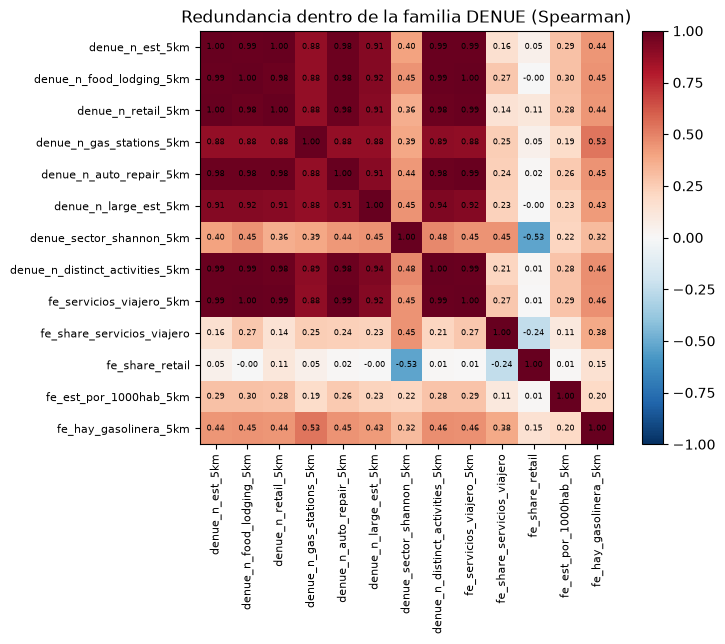

In [12]:
denue = [c for c in num_vt if c.startswith(("denue_", "fe_servicios", "fe_share", "fe_est_por", "fe_hay_gas"))]
m = train_fe[denue].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(m, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(denue)), denue, rotation=90, fontsize=8); ax.set_yticks(range(len(denue)), denue, fontsize=8)
for i in range(len(denue)):
    for j in range(len(denue)):
        ax.text(j, i, f"{m.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)
fig.colorbar(im); ax.set_title("Redundancia dentro de la familia DENUE (Spearman)"); plt.tight_layout(); plt.show()

### 4.3 Relevancia de las características

Las gasolineras mostraron una asociación importante con el tráfico: correlación absoluta **0.691** e información mutua **0.325**. Las intersecciones y la proporción rural a 10 km también presentaron asociación, con correlaciones absolutas **0.508** y **0.477**. Estas cifras no indican el signo de la relación ni demuestran causalidad.

Las seis categorías viales cumplieron el criterio de relevancia en el diagnóstico completo. La selección se volvió a calcular en cada entrenamiento, y la utilidad del conjunto se comprobó mediante validación espacial.


In [13]:
Xn = train_fe[num_filtro].fillna(train_fe[num_filtro].median())
F, pF = f_regression(Xn, train_fe[TARGET])
mi = mutual_info_regression(Xn, train_fe[TARGET], random_state=SEED)
relev = pd.DataFrame({"rho_spearman": rho_obj[num_filtro].round(3), "F": F.round(1), "p_F": pF,
                      "info_mutua": mi.round(3)}, index=num_filtro).sort_values("info_mutua", ascending=False)
print(relev.to_string())

anova = []
for c in CAT_COLS:
    grupos = [g[TARGET].values for _, g in train_fe.groupby(c) if len(g) >= 5]
    if len(grupos) > 1:
        f, p = stats.f_oneway(*grupos); anova.append({"variable": c, "F": round(f, 1), "p": p, "categorias": len(grupos)})
print(); print(pd.DataFrame(anova).sort_values("F", ascending=False).to_string(index=False))

                                       rho_spearman      F           p_F  info_mutua
denue_n_gas_stations_5km                      0.691  252.9  7.462514e-49       0.325
t2m_mean                                      0.373   82.3  1.160508e-18       0.269
ws10m_mean                                    0.081    1.6  2.035529e-01       0.214
prectotcorr_std                               0.422   68.6  6.116269e-16       0.207
ws10m_seasonal_amplitude                      0.328   77.4  1.060154e-17       0.199
rural_pop_share_10km                          0.477  178.8  1.706989e-36       0.190
fe_pop_urbana_10km                            0.338  123.2  1.784297e-26       0.181
rural_pop_share_20km                          0.441  126.3  4.621306e-27       0.181
prectotcorr_p10                               0.249    7.0  8.219518e-03       0.178
t2m_std                                       0.225   26.0  4.481044e-07       0.173
t2m_max_std                                   0.111    5.6  1.797

In [14]:
# Las categóricas sin diferencia significativa entre grupos (p ≥ 0.05) salen del modelo
cat_sel = [r["variable"] for r in anova if r["p"] < 0.05]
print("Categóricas que se conservan:", cat_sel)
decidir("4.3", f"Conservar categóricas con ANOVA p < 0.05: {cat_sel}", "El log_tdpa medio difiere entre sus categorías")

Categóricas que se conservan: ['road_tipo_vial', 'road_circula', 'road_cond_pav', 'road_recubri', 'road_administra', 'road_nivel']


### 4.4 Reducción de características climáticas

El PCA resumió **20 variables climáticas en 4 componentes**, conservando **92.6 %** de la variación del bloque en el diagnóstico. Esto permitió representar información correlacionada con menos columnas.

El porcentaje corresponde a la información climática conservada, no a la precisión de la predicción del tráfico. En cada entrenamiento se recalcularon las componentes necesarias.


20 columnas de clima -> 4 componentes explican 92.6% de la varianza
                                 PC1   PC2   PC3   PC4
prectotcorr_mean                0.19 -0.06  0.16  0.49
t2m_mean                        0.31  0.04  0.11 -0.07
t2m_max_mean                    0.26  0.10  0.25 -0.16
ws10m_mean                      0.04  0.49 -0.20  0.16
prectotcorr_std                 0.28 -0.10 -0.00  0.24
t2m_std                        -0.25  0.17  0.28  0.09
t2m_max_std                    -0.21  0.09  0.40  0.04
ws10m_std                       0.08  0.37 -0.01 -0.23
prectotcorr_p10                -0.10  0.07  0.29  0.47
t2m_p10                         0.31  0.00  0.06 -0.10
t2m_max_p10                     0.29  0.07  0.16 -0.14
ws10m_p10                       0.03  0.46 -0.21  0.21
prectotcorr_p90                 0.26 -0.09  0.05  0.35
t2m_p90                         0.29  0.07  0.17 -0.09
t2m_max_p90                     0.20  0.14  0.39 -0.13
ws10m_p90                       0.05  0.50 -0.19  0.

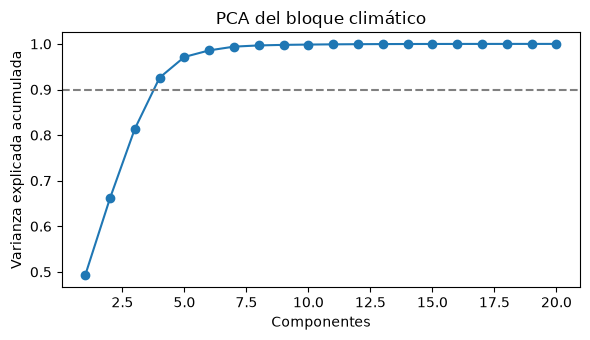

In [15]:
CLIMA = [c for c in num_vt if c.startswith(("prectotcorr", "t2m", "ws10m"))]
Xc = StandardScaler().fit_transform(train_fe[CLIMA].fillna(train_fe[CLIMA].median()))
pca_full = PCA(random_state=SEED).fit(Xc)
acum = np.cumsum(pca_full.explained_variance_ratio_)
N_PCA = int(np.searchsorted(acum, 0.90) + 1)
print(f"{len(CLIMA)} columnas de clima -> {N_PCA} componentes explican {acum[N_PCA-1]:.1%} de la varianza")

cargas = pd.DataFrame(pca_full.components_[:N_PCA].T, index=CLIMA,
                      columns=[f"PC{i+1}" for i in range(N_PCA)]).round(2)
print(cargas.to_string())

plt.figure(figsize=(6, 3.5))
plt.plot(range(1, len(acum) + 1), acum, marker="o"); plt.axhline(0.9, ls="--", c="gray")
plt.xlabel("Componentes"); plt.ylabel("Varianza explicada acumulada"); plt.title("PCA del bloque climático")
plt.tight_layout(); plt.show()
decidir("4.4", f"PCA del clima: {len(CLIMA)} columnas -> {N_PCA} componentes (≥90% de varianza)",
        "Diagnóstico exploratorio de redundancia; el PCA de CV se aprende por fold")

### Interpretación del PCA

Las componentes resumieron principalmente contrastes de temperatura y variación climática, régimen de viento, temperaturas máximas y nivel de precipitación. Esta interpretación se obtuvo de las contribuciones de las variables originales. Las componentes no se consideraron mediciones físicas nuevas ni causas del tráfico.


### 4.5 Prueba: ¿la selección mejora o empeora la predicción?

Se compararon **12 configuraciones**: todas las características, filtro y filtro con PCA; con y sin recorte; y con Ridge o GBoost. El modelo de referencia se evaluó en las mismas cinco particiones espaciales.

| Partición | Sitios de entrenamiento después de separación | Sitios de validación |
|---|---:|---:|
| 1 | 127 | 141 |
| 2 | 150 | 141 |
| 3 | 197 | 141 |
| 4 | 105 | 140 |
| 5 | 138 | 140 |

La separación de 40 km redujo la muestra de entrenamiento para limitar el solapamiento territorial. Los radios originales de las variables se mantuvieron. Cada entrenamiento ajustó nuevamente la preparación y selección, sin usar los valores de tráfico de validación.

Se calcularon RMSE y MAE: valores menores representan menor error. Las métricas corresponden al logaritmo del tráfico, no directamente a vehículos diarios. La variación entre particiones no equivale a una prueba de diferencia estadística entre modelos.


In [16]:
gkf=GroupKFold(n_splits=min(5,train_fe.group_block25.nunique()))
y=train_fe[TARGET]
folds=[]
for fold,(tr,va) in enumerate(gkf.split(train_fe,y,train_fe.group_block25),1):
    a=purgar_espacial(train_fe.iloc[tr],train_fe.iloc[va])
    if len(a)<20: raise ValueError(f"Fold {fold}: solo {len(a)} filas después de purgar; revise cobertura o margen")
    assert not set(a.group_block25)&set(train_fe.iloc[va].group_block25)
    folds.append((fold,a.index,train_fe.iloc[va].index))
print("Tamaños por fold:",[(k,len(a),len(b)) for k,a,b in folds])

def modelo_seguro(modo,recortar,modelo):
    m=Ridge(alpha=1.0) if modelo=="Ridge" else HistGradientBoostingRegressor(max_iter=150,learning_rate=0.05,early_stopping=False,random_state=SEED)
    return Pipeline([("prep",PreparadorSeguro(modo=modo,recortar=recortar)),("m",m)])

res=[];detalle=[]
configuraciones=[(modo,cap,m) for modo in ["Todas","Filtro","Filtro + PCA"] for cap in [False,True] for m in ["Ridge","GBoost"]]
for modo,cap,mn in [("Baseline",False,"Baseline")]+configuraciones:
    errores=[];maes=[];dim=[]
    for k,a,b in folds:
        m=BaselineGrupo() if modo=="Baseline" else modelo_seguro(modo,cap,mn)
        m.fit(train_fe.loc[a],y.loc[a]);p=m.predict(train_fe.loc[b])
        er=mean_squared_error(y.loc[b],p)**0.5;ma=mean_absolute_error(y.loc[b],p)
        errores.append(er);maes.append(ma)
        nf=2 if modo=="Baseline" else len(m.named_steps["prep"].feature_names_out_)
        dim.append(nf)
        detalle.append(dict(conjunto=modo,recorte=cap,modelo=mn,fold=k,n_train=len(a),n_valid=len(b),n_features=nf,RMSE=er,MAE=ma))
    res.append(dict(conjunto=modo,recorte=cap,modelo=mn,n_features=np.mean(dim),RMSE=np.mean(errores),RMSE_sd=np.std(errores,ddof=1),MAE=np.mean(maes)))
    print(modo,"recorte",cap,mn,"RMSE",round(np.mean(errores),4),flush=True)
res=pd.DataFrame(res)
res["mejora_vs_baseline_%"]=(1-res.RMSE/res.loc[res.conjunto.eq("Baseline"),"RMSE"].iloc[0])*100
print(res.round(4).to_string(index=False))


Tamaños por fold: [(1, 127, 141), (2, 150, 141), (3, 197, 141), (4, 105, 140), (5, 138, 140)]
Baseline recorte False Baseline RMSE 1.1237
Todas recorte False Ridge RMSE 0.8742
Todas recorte False GBoost RMSE 0.755
Todas recorte True Ridge RMSE 0.8524
Todas recorte True GBoost RMSE 0.755
Filtro recorte False Ridge RMSE 0.7601
Filtro recorte False GBoost RMSE 0.7504
Filtro recorte True Ridge RMSE 0.7514
Filtro recorte True GBoost RMSE 0.7502
Filtro + PCA recorte False Ridge RMSE 0.7554
Filtro + PCA recorte False GBoost RMSE 0.7312
Filtro + PCA recorte True Ridge RMSE 0.7503
Filtro + PCA recorte True GBoost RMSE 0.7351
    conjunto  recorte   modelo  n_features   RMSE  RMSE_sd    MAE  mejora_vs_baseline_%
    Baseline    False Baseline         2.0 1.1237   0.1385 0.9040                0.0000
       Todas    False    Ridge       184.4 0.8742   0.1656 0.6738               22.2063
       Todas    False   GBoost       184.4 0.7550   0.0561 0.5801               32.8085
       Todas     True   

In [17]:
# Elegir configuración+modelo por RMSE CV. La prueba externa no participa.
elegida=res.loc[~res.conjunto.eq("Baseline")].sort_values(["RMSE","n_features"]).iloc[0]
FINAL=elegida["conjunto"]
modelo_final=modelo_seguro(FINAL,bool(elegida.recorte),elegida.modelo).fit(train_fe,y)
pred_test=modelo_final.predict(test_fe)
metricas_test=pd.DataFrame([dict(conjunto=FINAL,recorte=bool(elegida.recorte),modelo=elegida.modelo,n_test=len(test_fe),
    RMSE_log=mean_squared_error(test_fe[TARGET],pred_test)**0.5,MAE_log=mean_absolute_error(test_fe[TARGET],pred_test))])
print("Configuración elegida:",elegida.to_dict());print("Prueba externa reservada:");print(metricas_test.to_string(index=False))
decidir("4.5",f"Elegido {FINAL}; recorte={bool(elegida.recorte)}; modelo={elegida.modelo}","Menor RMSE CV espacial; prueba externa solo al final")


Configuración elegida: {'conjunto': 'Filtro + PCA', 'recorte': False, 'modelo': 'GBoost', 'n_features': 66.8, 'RMSE': 0.7312255391531159, 'RMSE_sd': 0.05715027199258278, 'MAE': 0.5688535023153085, 'mejora_vs_baseline_%': 34.92862492126642}
Prueba externa reservada:
    conjunto  recorte modelo  n_test  RMSE_log  MAE_log
Filtro + PCA    False GBoost      23    0.6634 0.495438


### Resultados de la comparación

| Configuración | RMSE de validación | MAE de validación | Columnas transformadas promedio |
|---|---:|---:|---:|
| Modelo de referencia | 1.1237 | 0.9040 | 2.0 |
| Todas · GBoost · sin recorte | 0.7550 | 0.5801 | 184.4 |
| Filtro · GBoost · sin recorte | 0.7504 | 0.5776 | 52.4 |
| **Filtro + PCA · GBoost · sin recorte** | 0.7312 | 0.5689 | 66.8 |
| Filtro + PCA · GBoost · con recorte | 0.7351 | 0.5710 | 66.8 |

El filtro redujo las columnas promedio de **184.4 a 52.4**, con un error ligeramente menor que el conjunto completo. La combinación con PCA obtuvo el menor RMSE entre las alternativas evaluadas.

Se seleccionó **GBoost con filtro y PCA sin recorte**, con RMSE **0.7312**, MAE **0.5689** y una reducción del RMSE de **34.93 %** frente al modelo de referencia. La variante con recorte registró RMSE **0.7351**; por ello, el tratamiento seleccionado conserva los extremos y mantiene las transformaciones y sus indicadores. La diferencia es pequeña y no constituye una mejora estadísticamente demostrada.

Las **66.8 columnas** son un promedio entre particiones. El modelo ajustado finalmente con los 703 sitios recibió **95 columnas transformadas**. Son medidas diferentes, porque la selección y codificación se ajustan nuevamente en cada entrenamiento.

En los **23 sitios de prueba externa**, el modelo obtuvo RMSE **0.6634** y MAE **0.4954**. Estos resultados describen el corredor reservado y no garantizan el mismo desempeño en otras regiones. La reducción del 34.93 % corresponde a validación, no a una comparación externa con el modelo de referencia.


### 4.6 Alcance de la interpretación territorial

Las variables describen condiciones asociadas con el tráfico, sin establecer relaciones causales. Los indicadores nuevos se construyeron en la preparación de datos y su utilidad se evaluó mediante modelos.

El TDPA puede apoyar la planificación de infraestructura, pero no equivale a demanda de carga eléctrica. Esta última requiere información adicional sobre vehículos eléctricos, necesidades de recarga y energía por sesión.


## 5. Archivos generados

Se conservaron únicamente las salidas del notebook original:

| Archivo | Contenido |
|---|---|
| `FE_TOP_Model_Table.csv` | Tabla con las nuevas características y los indicadores de calidad. |
| `fe_feature_list.csv` | Variables seleccionadas, su tipo y transformación. |
| `fe_decisiones.csv` | Registro de decisiones de preparación. |
| `FE_CTN_Prediction_Table.csv` | Tabla preparada para los puntos de predicción; se generó en esta ejecución. |

Las salidas se guardaron junto a la tabla maestra, en:

```text
D:\TEC DE MONTERREY\maestria\Proyecto integrador\Equipo20_EnergyIntelligence\03_PROCESSED
```

El ajuste final utilizó **95 columnas transformadas**. La lista exportada contiene 27 numéricas, 40 indicadores de atípicos, 6 categóricas y 20 variables climáticas que ingresan al PCA. Sus **93 filas** no equivalen a las 95 columnas: las categorías se expanden y las variables climáticas se resumen.

Las métricas permanecen en el notebook y no se guardan archivos adicionales. La preparación ajustada permanece en `modelo_final` durante la sesión. Los avisos de fragmentación del DataFrame corresponden a rendimiento interno de pandas; no interrumpieron la exportación mostrada.


In [18]:
# Se conservan únicamente los archivos del notebook original.
prep_final = modelo_final.named_steps["prep"]
features_finales = pd.DataFrame(
    [{"feature": c, "tipo": "numérica", "transformacion":
      "Sin transformación (0/1)" if c in prep_final.binarias_ else
      ("Yeo-Johnson + escalamiento robusto" if c in prep_final.yj_ else "Escalamiento robusto")}
     for c in prep_final.num_seleccionadas_]
    + [{"feature": c, "tipo": "indicador de atípico", "transformacion": "Sin transformación (0/1)"}
       for c in prep_final.flags_cols_]
    + [{"feature": c, "tipo": "categórica", "transformacion": "One-hot"}
       for c in prep_final.cat_seleccionadas_]
    + [{"feature": c, "tipo": "clima -> PCA", "transformacion":
        f"PCA ({prep_final.pca_.n_components_} comp.)"}
       for c in prep_final.pca_cols_],
    columns=["feature", "tipo", "transformacion"])
features_finales.to_csv(PROCESSED / "fe_feature_list.csv", index=False)

fe_full = construir_features(t)
fe_full.to_csv(PROCESSED / "FE_TOP_Model_Table.csv", index=False)

ctn_file = PROCESSED / "CTN_Prediction_Table.csv"
if ctn_file.exists():
    ctn = pd.read_csv(ctn_file)
    faltan = set(t.columns) - set(ID_COLS + OBJETIVO + SOLO_AFORO + COORDS + CALIDAD + DOMINIO) - set(ctn.columns)
    faltan |= (set(CAT_COLS) | {"mun_assignment_method"}) - set(ctn.columns)
    if faltan:
        print("CTN no procesada: faltan columnas", sorted(faltan))
    else:
        construir_features(ctn).to_csv(PROCESSED / "FE_CTN_Prediction_Table.csv", index=False)
        print("CTN con las mismas características: FE_CTN_Prediction_Table.csv")

pd.DataFrame(decisiones).to_csv(PROCESSED / "fe_decisiones.csv", index=False)
n_efectivas = len(prep_final.feature_names_out_)
print(f"Conjunto final: {FINAL} | columnas transformadas del modelo: {n_efectivas}")
print(features_finales.groupby("tipo").size().to_string())
print("Resultados guardados en:", PROCESSED.resolve())


CTN con las mismas características: FE_CTN_Prediction_Table.csv
Conjunto final: Filtro + PCA | columnas transformadas del modelo: 95
tipo
categórica               6
clima -> PCA            20
indicador de atípico    40
numérica                27
Resultados guardados en: D:\TEC DE MONTERREY\maestria\Proyecto integrador\Equipo20_EnergyIntelligence\03_PROCESSED


C:\Users\User\AppData\Local\Temp\ipykernel_20976\3320116524.py:65: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["fe_rnc_sin_atributos"]=d.road_cond_pav.isna().astype(int)
C:\Users\User\AppData\Local\Temp\ipykernel_20976\3320116524.py:67: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["fe_municipio_proxy"]=d.mun_assignment_method.eq("nearest_locality_proxy").astype(int)


In [19]:
print(pd.DataFrame(decisiones).to_string(index=False))

paso                               ambito                                                                                                                                       decision                                                                                                            razon
   1      regla de dominio o ajuste final                                                                                         Excluir columnas que solo existen donde hay aforo SICT                        No están disponibles para los CTN del corredor; pct_C y pct_B se miden con el TDPA (fuga)
   1      regla de dominio o ajuste final                                                                                                                                Excluir lat/lon                                             Evitar que el modelo memorice ubicaciones; la validación es espacial
   1      regla de dominio o ajuste final                                                                 

## 6. Conclusiones de la fase de Preparación de los datos (CRISP-ML)

En CRISP-ML(Q), la preparación de los datos convierte la información de la fase anterior en un conjunto adecuado para modelar. En este avance se integraron selección, limpieza, construcción y transformación, junto con una evaluación de la utilidad de las características. Las decisiones se ajustaron dentro de cada entrenamiento para reducir el riesgo de fuga de información.

**Selección de datos.** De las **102 columnas** de la tabla maestra se excluyeron identificadores, coordenadas como predictores y variables disponibles únicamente en sitios con aforo SICT, como `pct_C`, `pct_B` y `n_te`. Se reservaron **23 sitios de la MEX-095D** para prueba externa. De los **1,052** candidatos restantes se excluyeron **349** por bloque compartido o proximidad al corredor, quedando **703 sitios** para desarrollo y ajuste final. El margen de separación de **40 km** no cambió los radios territoriales originales de 5, 10 y 20 km.

**Limpieza.** La distancia mediana a la vía asignada fue de **3.5 m** en los 703 sitios; **3** superaron 500 m y se conservaron para revisión. Los atributos de pavimento, recubrimiento y administración fueron desconocidos en **173 sitios (24.61 %)** y se representaron como una categoría propia. Se diferenciaron faltantes estructurales y desconocidos mediante indicadores, sin confundir ausencia de datos con ausencia real de población o servicios. Los desconocidos numéricos se completaron dentro del entrenamiento. Los indicadores de peaje de RNC y SICT coincidieron en **93.40 %** de la base completa, con **71 discrepancias** pendientes de revisión.

**Construcción.** Se mantuvieron los indicadores de servicios al viajero, comercio, concentración poblacional, carriles, peaje e intensidad agrícola. Se añadieron densidades, población entre radios y proporciones agrícolas, junto con indicadores de calidad. Estas características describen el territorio usando la información existente; algunas repiten información y pueden retirarse durante la selección. El modelo de referencia por tipo de vía y peaje mostró medias de tráfico logarítmico de **8.96** en carreteras sin peaje y **9.87** en carreteras con peaje. Esta diferencia describe una asociación entre grupos, sin demostrar un efecto causal.

**Transformación y estandarización.** Las continuas seleccionadas con asimetría elevada se transformaron con Yeo–Johnson, que admite ceros y valores negativos. Se utilizó escalamiento robusto para moderar la influencia de extremos y estandarización para el bloque climático que ingresó al PCA. Los indicadores binarios conservaron sus valores 0/1 y sus faltantes se completaron con la categoría más frecuente del entrenamiento. Las seis categorías viales se representaron mediante one-hot, agrupando las poco frecuentes. También se comparó conservar o recortar valores extremos; la configuración seleccionada los conservó.

**Reducción de dimensionalidad.** En el diagnóstico se identificaron **234 numéricas candidatas** y se retiraron **135 constantes**. Tras excluir también las columnas variables de radiación, quedaron **94 numéricas**, de las cuales el filtro de correlación conservó **45**. La radiación permaneció en la tabla para análisis energético. El PCA resumió **20 variables climáticas en 4 componentes**, conservando **92.6 %** de su variación. Las seis categorías viales cumplieron el criterio ANOVA del diagnóstico. Estas decisiones se volvieron a calcular en cada entrenamiento; las listas del diagnóstico no se impusieron a la validación.

**Resultado.** Se compararon los conjuntos completo, filtrado y filtrado con PCA, con y sin recorte, mediante Ridge y GBoost. El filtro redujo las columnas transformadas promedio de **184.4 a 52.4**, con un error ligeramente menor para GBoost sin recorte. Se seleccionó **Filtro + PCA y GBoost sin recorte**, con **RMSE de validación 0.7312**, **MAE 0.5689** y una reducción del RMSE de **34.93 %** frente al modelo de referencia. El promedio fue de **66.8 columnas** entre particiones, mientras el ajuste final utilizó **95**. En la prueba externa se obtuvo **RMSE 0.6634** y **MAE 0.4954**. Todas estas métricas están en escala logarítmica, sin expresar directamente vehículos diarios ni demanda eléctrica.

**Riesgos que pasan a la fase de Modelado.**

- Las variables DENUE describen asociaciones: la actividad económica también puede ser consecuencia del tráfico.
- Las discrepancias de peajes requieren revisión; **60 sitios** aparecen con cuota en SICT y sin peaje en RNC. La asignación a una carretera libre paralela sigue siendo una posible explicación, no una causa confirmada.
- La no aplicabilidad de escolaridad y electricidad en zonas sin población permanece como hipótesis por confirmar. Los datos agrícolas mantienen su alcance municipal y su asignación por localidad cercana.
- La representación territorial deberá revisarse por estado, incluyendo Estado de México y Guerrero. El porcentaje histórico de concentración de sitios no se presenta como un resultado actualizado, pues no se recalculó en las salidas mostradas.
- La prueba externa de **23 sitios** y las muestras pequeñas después de la separación espacial limitan la generalización. En la fase siguiente conviene estimar la incertidumbre mediante intervalos de confianza; estos no se calcularon en esta ejecución. La selección entre configuraciones también puede producir un error de validación optimista.

La lista de características (`fe_feature_list.csv`), las tablas preparadas para sitios y CTN y la bitácora (`fe_decisiones.csv`) se conservaron en **03_PROCESSED** como entrada para el Avance 3. Los resultados respaldan la estimación del tráfico en el conjunto evaluado; la demanda de carga eléctrica requiere información o supuestos adicionales.
